In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.gofplots import qqplot

from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import (LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

print("All packages loaded successfully")

All packages loaded successfully


In [2]:
data = pd.read_excel("ENB2012_data 2.xlsx")

In [3]:
data.head

<bound method NDFrame.head of        X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0    0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1    0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2    0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3    0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4    0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28
..    ...    ...    ...     ...  ...  ..  ...  ..    ...    ...
763  0.64  784.0  343.0  220.50  3.5   5  0.4   5  17.88  21.40
764  0.62  808.5  367.5  220.50  3.5   2  0.4   5  16.54  16.88
765  0.62  808.5  367.5  220.50  3.5   3  0.4   5  16.44  17.11
766  0.62  808.5  367.5  220.50  3.5   4  0.4   5  16.48  16.61
767  0.62  808.5  367.5  220.50  3.5   5  0.4   5  16.64  16.03

[768 rows x 10 columns]>

In [4]:
data.columns = ['X1_Compactness', 'X2_SurfaceArea', 'X3_WallArea', 'X4_RoofArea',
                'X5_Height', 'X6_Orientation', 'X7_GlazingArea', 'X8_GlazingDist',
                'Y1_HeatingLoad', 'Y2_CoolingLoad']

features = [c for c in data.columns if c.startswith('X')]
feature_labels = {
    'X1_Compactness': 'Relative Compactness',
    'X2_SurfaceArea': 'Surface Area',
    'X3_WallArea': 'Wall Area',
    'X4_RoofArea': 'Roof Area',
    'X5_Height': 'Overall Height',
    'X6_Orientation': 'Orientation',
    'X7_GlazingArea': 'Glazing Area',
    'X8_GlazingDist': 'Glazing Area Distribution'
}

print(f"Shape:  {data.shape}")
print(f"Missing values: {data.isnull().sum()}")

Shape:  (768, 10)
Missing values: X1_Compactness    0
X2_SurfaceArea    0
X3_WallArea       0
X4_RoofArea       0
X5_Height         0
X6_Orientation    0
X7_GlazingArea    0
X8_GlazingDist    0
Y1_HeatingLoad    0
Y2_CoolingLoad    0
dtype: int64


In [5]:
data.describe().T.style.format('{:.3f}')\
    .background_gradient(cmap = 'Blues', subset = ['mean', 'std']) \
    .background_gradient(cmap = 'Oranges', subset = ['min', 'max'])

,count,mean,std,min,25%,50%,75%,max
X1_Compactness,768.000,0.764,0.106,0.620,0.682,0.750,0.830,0.980
X2_SurfaceArea,768.000,671.708,88.086,514.500,606.375,673.750,741.125,808.500
X3_WallArea,768.000,318.500,43.626,245.000,294.000,318.500,343.000,416.500
X4_RoofArea,768.000,176.604,45.166,110.250,140.875,183.750,220.500,220.500
X5_Height,768.000,5.250,1.751,3.500,3.500,5.250,7.000,7.000
X6_Orientation,768.000,3.500,1.119,2.000,2.750,3.500,4.250,5.000
X7_GlazingArea,768.000,0.234,0.133,0.000,0.100,0.250,0.400,0.400
X8_GlazingDist,768.000,2.812,1.551,0.000,1.750,3.000,4.000,5.000
Y1_HeatingLoad,768.000,22.307,10.090,6.010,12.992,18.950,31.668,43.100
Y2_CoolingLoad,768.000,24.588,9.513,10.900,15.620,22.080,33.133,48.030


In [6]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

BLUE   = '#378ADD'
CORAL  = '#D85A30'
TEAL   = '#1D9E75'
AMBER  = '#BA7517'
PURPLE = '#7F77DD'

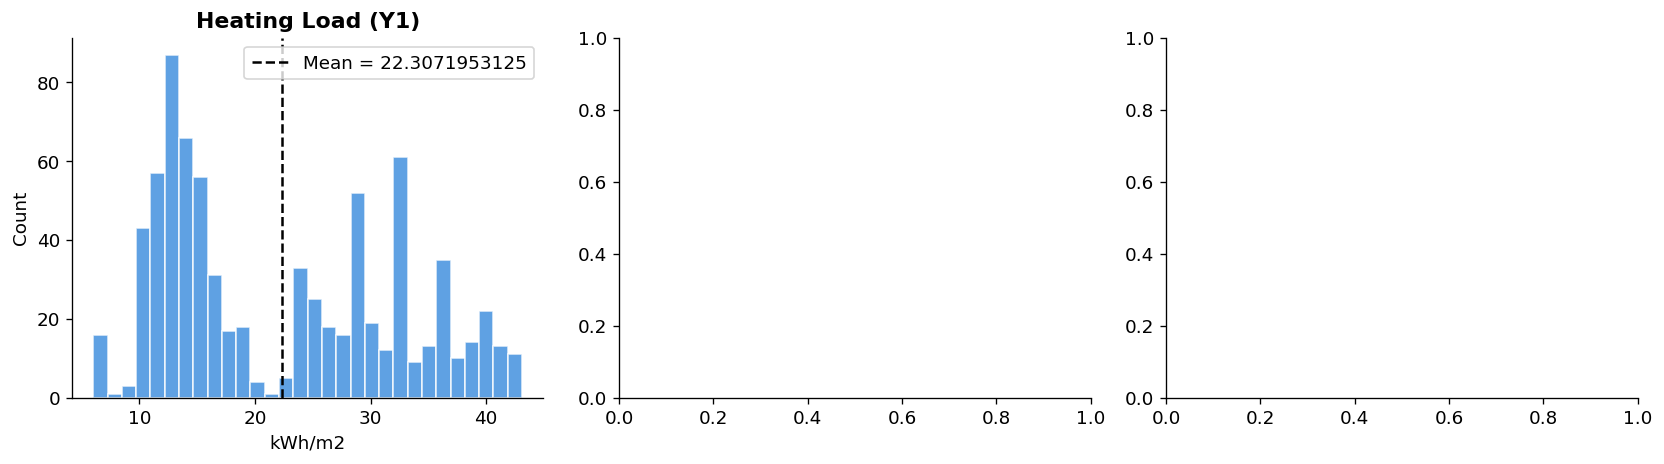

<Figure size 768x576 with 0 Axes>

<Figure size 768x576 with 0 Axes>

In [7]:
fig, axes = plt.subplots(1,3, figsize = (14,4))

for ax, col, colour, label in zip (
    axes,
    ['Y1_HeatingLoad', 'Y2_CoolingLoad', None],
    [BLUE, CORAL, TEAL],
    ['Heating Load (Y1)', 'Cooling Load (Y2)', 'Y1 vs Y2']):
    if col is not None:
        ax.hist(data[col], bins = 30, color = colour, alpha = 0.80, edgecolor = 'white')
        ax.axvline(data[col].mean(), color = 'black', lw = 1.5, ls = '--', 
                   label= f'Mean = {data[col].mean()}')
        ax.set_title(label, fontweight = 'bold')
        ax.set_xlabel('kWh/m2'); ax.set_ylabel('Count')
        ax.legend()
    else:
        ax.scatter(data['Y1_HeatingLoad'], data['Y2_CoolingLoad'], alpha = 0.30, s = 15, color = TEAL)
        m, b = np.polyfit(data['Y1_HeatingLoad'], data['Y2_CoolingLoad'], 1)
        xs = np.linspace(data['Y1_HeatingLoad'].min(), data['Y1_HeatingLoad'].max(), 100)
        ax.plot(xs, m*xs+b, color = 'black', lw = 1.5)
        r = data[['Y1_HeatingLoad', 'Y2_CoolingLoad']].corr().iloc[0,1]
        ax.set_title(f'Y1 vs Y2 (r = {r:.3f})', fontweight = 'bold')
        ax.set_xlabel('Heating Load'); ax.set_ylabel('Cooling Load')
    plt.tight_layout()
    plt.show()

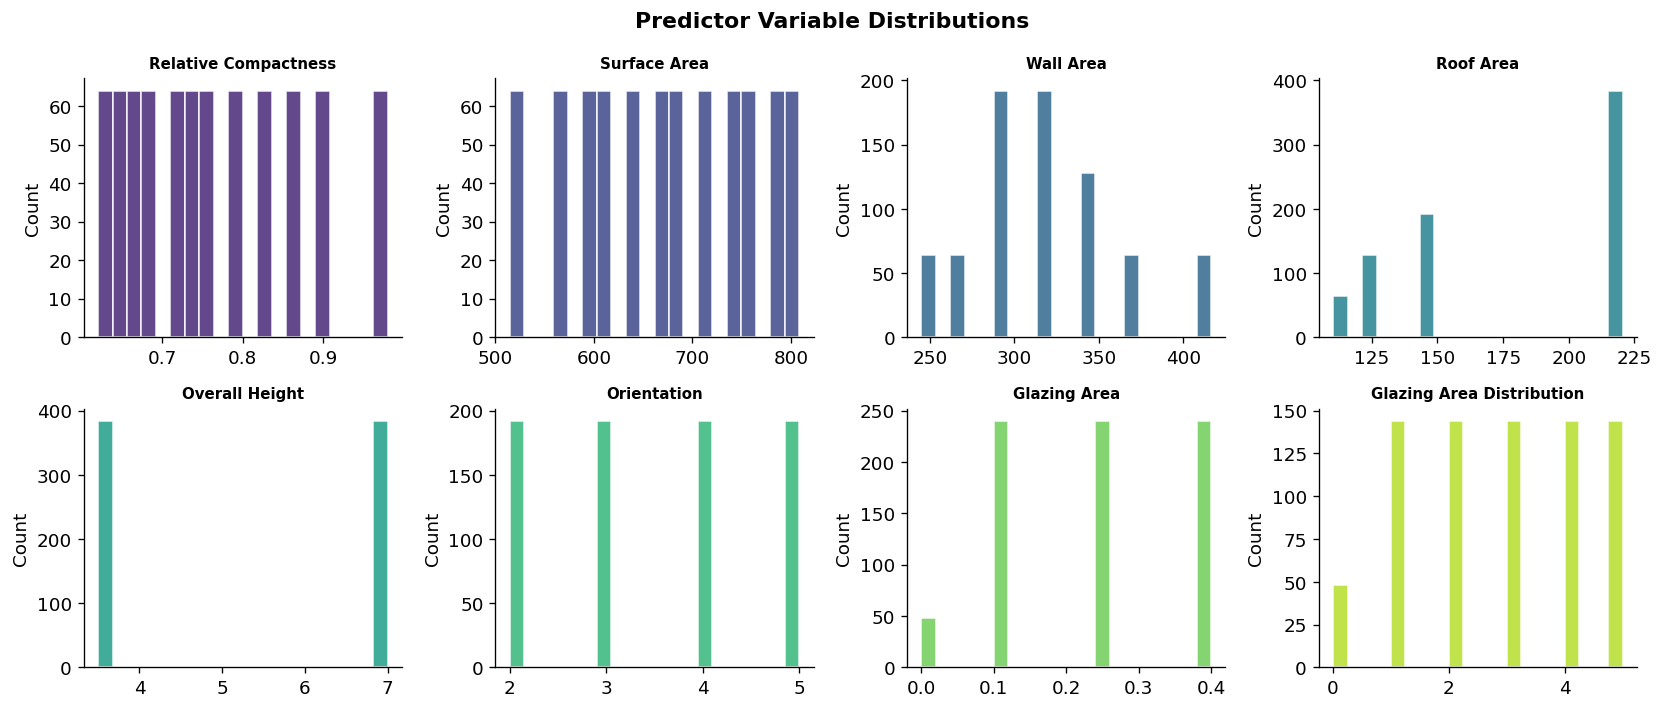

In [8]:
fig, axes = plt.subplots(2, 4, figsize = (14,6))
colours = sns.color_palette('viridis', 8)

for ax, feat, colour in zip(axes.flat, features, colours):
    ax.hist(data[feat], bins = 20, color = colour, alpha = 0.85, edgecolor = 'white')
    ax.set_title(feature_labels[feat], fontsize = 9, fontweight = 'bold')
    ax.set_xlabel(''); ax.set_ylabel('Count')

plt.suptitle('Predictor Variable Distributions', fontweight = 'bold')
plt.tight_layout()
plt.show()

Pearson Correlation Matrix

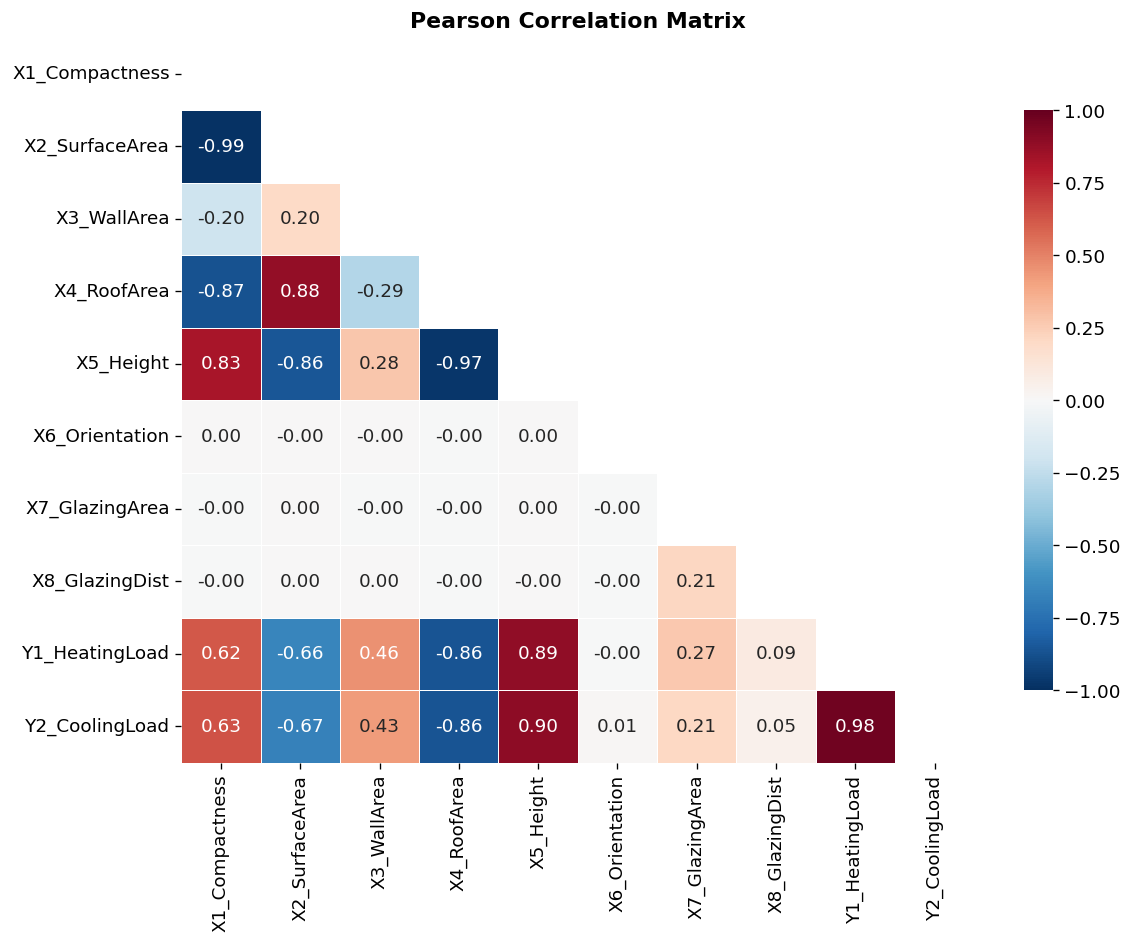

In [9]:
corr = data.corr()

mask = np.triu(np.ones_like(corr, dtype = bool))
fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(corr, mask = mask, annot = True, fmt = '.2f', cmap='RdBu_r',
           center = 0, vmin = -1, vmax  = 1, linewidths = 0.5, 
            cbar_kws = {'shrink': 0.8}, ax=ax)

ax.set_title('Pearson Correlation Matrix', fontweight = 'bold')
plt.tight_layout()
plt.show()

In [10]:
print("Correlations with Y1 (sorted by absolute value):")
print(corr['Y1_HeatingLoad'].drop('Y1_HeatingLoad').abs().sort_values(ascending=False))

Correlations with Y1 (sorted by absolute value):
Y2_CoolingLoad   0.9759
X5_Height        0.8894
X4_RoofArea      0.8618
X2_SurfaceArea   0.6581
X1_Compactness   0.6223
X3_WallArea      0.4557
X7_GlazingArea   0.2698
X8_GlazingDist   0.0874
X6_Orientation   0.0026
Name: Y1_HeatingLoad, dtype: float64


Feature-Response Scatter Plots

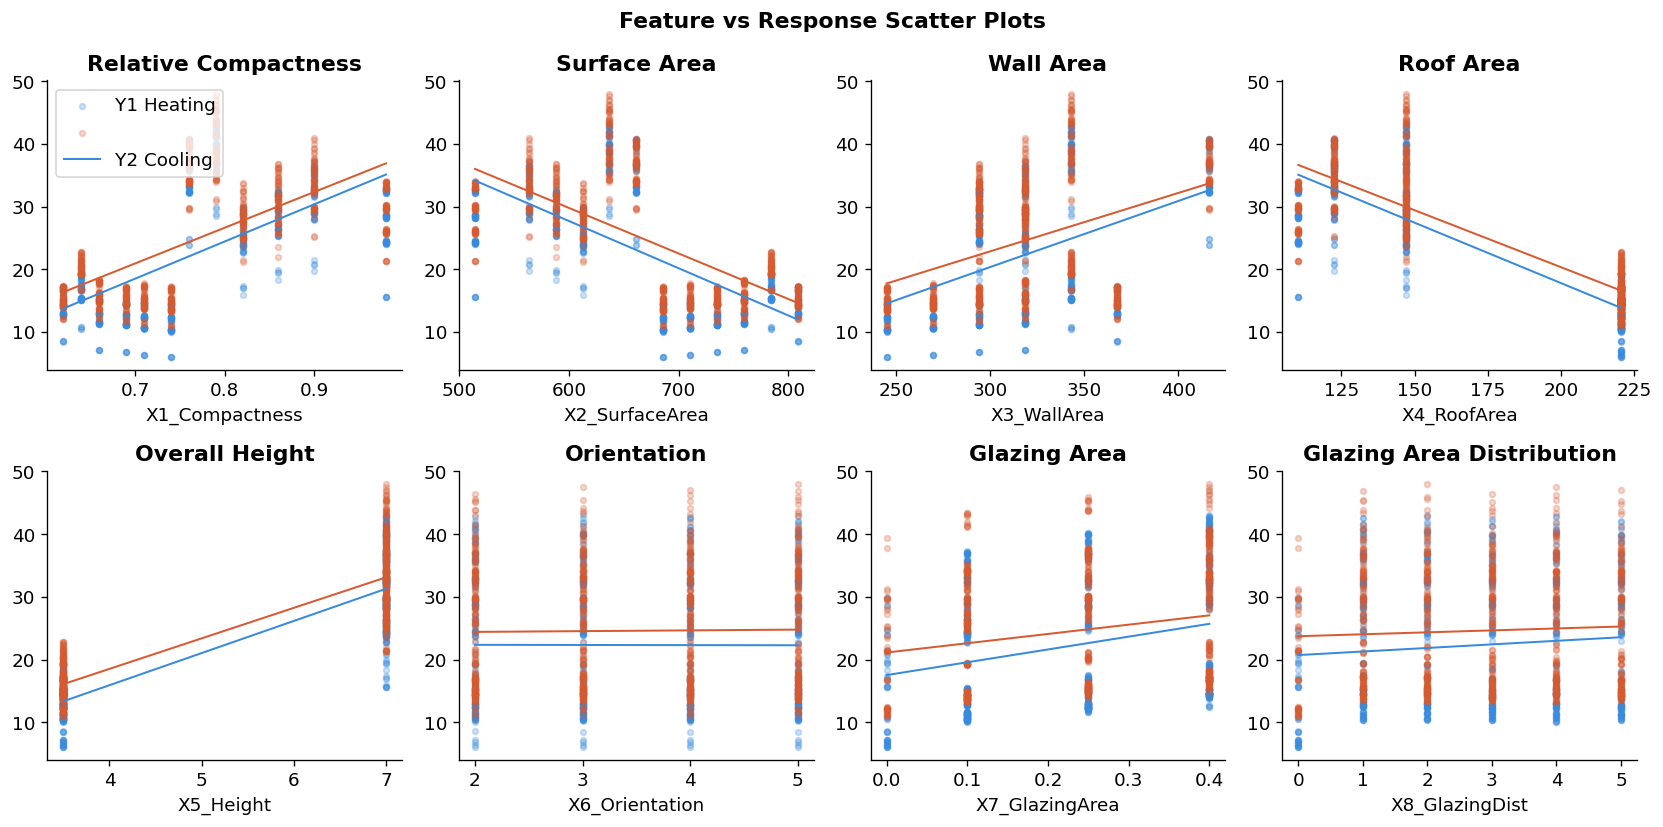

In [11]:
fig, axes = plt.subplots(2, 4, figsize = (14,7))

for ax, feat in zip(axes.flat, features):
    ax.scatter(data[feat], data['Y1_HeatingLoad'], alpha = 0.25, s = 12, color = BLUE, label = 'Y1')
    ax.scatter(data[feat], data['Y2_CoolingLoad'], alpha = 0.25, s = 12, color = CORAL, label = 'Y2')

    #OLS Trend Lines
    for y_col, col in [('Y1_HeatingLoad', BLUE), ('Y2_CoolingLoad', CORAL)]:
        m, b = np.polyfit(data[feat], data[y_col], 1)
        xs = np.linspace(data[feat].min(), data[feat].max(), 100)
        ax.plot(xs, m*xs+b, color = col, lw = 1.2)
    ax.set_title(feature_labels[feat], fontweight = 'bold')
    ax.set_xlabel(feat)

axes[0,0].legend(['Y1 Heating', '' , 'Y2 Cooling'], loc = 'upper left')
plt.suptitle('Feature vs Response Scatter Plots', fontweight = 'bold')
plt.tight_layout()
plt.show()

Data Preparation

In [12]:
X = data[features].copy()
y1 = data['Y1_HeatingLoad'].copy()
y2 = data['Y2_CoolingLoad'].copy()

X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split( X, y1, y2, test_size = 0.2, random_state = 42)

#Standardize the data. Standardization is required for Ridge, Lasso and ElasticNet do that penalty will be feature agnostic
scaler = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test = scaler.transform(X_test)

#Dataframes with feature names (for statsmodel)
Xs_train_df = pd.DataFrame(Xs_train, columns = features, index = X_train.index)
Xs_test_df = pd.DataFrame(Xs_test, columns = features, index = X_test.index)

print(f"Train size : {X_train.shape[0]} observations ({X_train.shape[0]/len(X)*100}%)")
print(f"Test size : {X_test.shape[0]} observations ({X_test.shape[0]/len(X)*100}%)")

def regression_metrics(y_true, y_pred, model_name, response):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {'Model': model_name, 'Response': response,
            'R²': round(r2, 4), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}

all_results = []

Train size : 614 observations (79.94791666666666%)
Test size : 154 observations (20.052083333333336%)


__Ordinary Least Squares (OLS) Regression__

- OLS finds beta that minimises the Residual Sum of Squares
- Under Gauss-Markov assumptions (Linearity, Exogeneity, Homoscedasticity and no perfect collinearity), OLS is the best linear unbaised estimator

In [13]:
# Model Fitting - Heating Load (Y1)
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

ols_y1 = sm.OLS(y1_train, X_train_sm).fit()
print(ols_y1.summary())

                            OLS Regression Results                            
Dep. Variable:         Y1_HeatingLoad   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     957.3
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:45:16   Log-Likelihood:                -1523.5
No. Observations:                 614   AIC:                             3063.
Df Residuals:                     606   BIC:                             3098.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             79.7270     21.123      3.

In [14]:
# OLS - Cooling Load (Y2)
ols_y2 = sm.OLS(y2_train, X_train_sm).fit()
print(ols_y2.summary())

                            OLS Regression Results                            
Dep. Variable:         Y2_CoolingLoad   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     672.3
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          7.77e-281
Time:                        15:45:16   Log-Likelihood:                -1585.0
No. Observations:                 614   AIC:                             3186.
Df Residuals:                     606   BIC:                             3221.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            100.5945     23.351      4.

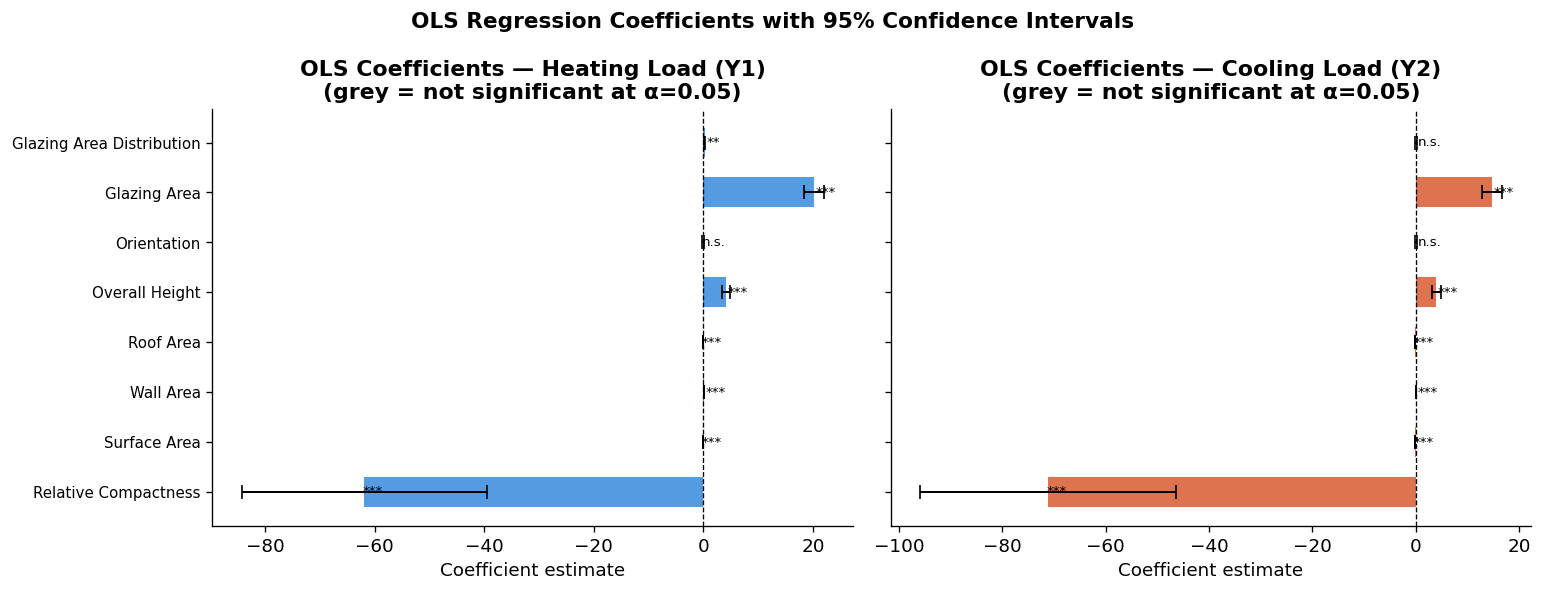

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, model, colour, title in zip(
        axes,
        [ols_y1, ols_y2],
        [BLUE, CORAL],
        ['Heating Load (Y1)', 'Cooling Load (Y2)']):

    coefs  = model.params[1:]         
    cis    = model.conf_int().iloc[1:]
    pvals  = model.pvalues[1:]
    sig    = pvals < 0.05

    y_pos  = range(len(coefs))
    bars   = ax.barh(y_pos, coefs.values,
                     color=[colour if s else '#CCCCCC' for s in sig],
                     alpha=0.85, height=0.6)

    # 95% CI error bars
    xerr_lo = coefs.values - cis[0].values
    xerr_hi = cis[1].values - coefs.values
    ax.errorbar(coefs.values, y_pos,
                xerr=[xerr_lo, xerr_hi],
                fmt='none', color='black', capsize=4, lw=1.2)

    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([feature_labels[f] for f in coefs.index], fontsize=9)
    ax.set_title(f'OLS Coefficients — {title}\n(grey = not significant at α=0.05)',
                 fontweight='bold')
    ax.set_xlabel('Coefficient estimate')

    # Annotate p-values
    for i, (coef, pv) in enumerate(zip(coefs.values, pvals)):
        stars = '***' if pv<0.001 else '**' if pv<0.01 else '*' if pv<0.05 else 'n.s.'
        ax.text(coef + np.sign(coef)*0.3, i, stars, va='center', fontsize=8)

plt.suptitle('OLS Regression Coefficients with 95% Confidence Intervals',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Multicollinearity - Variance Inflation Factors

                                Full Name      VIF         Severity
Feature                                                            
X1_Compactness       Relative Compactness 173.4623     Severe (>10)
X2_SurfaceArea               Surface Area      inf     Severe (>10)
X3_WallArea                     Wall Area      inf     Severe (>10)
X4_RoofArea                     Roof Area      inf     Severe (>10)
X5_Height                  Overall Height 133.8697     Severe (>10)
X6_Orientation                Orientation  11.0661     Severe (>10)
X7_GlazingArea               Glazing Area   4.2707  Acceptable (<5)
X8_GlazingDist  Glazing Area Distribution   4.4501  Acceptable (<5)


C:\Users\NGIGI\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


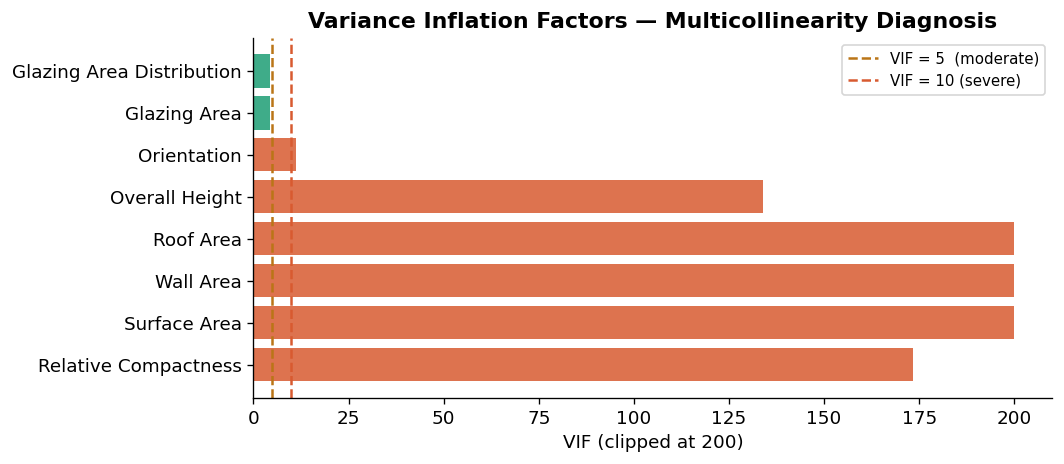


Note: Infinite VIF values indicate exact linear dependency among X1–X4.
This arises because Compactness = Volume / Surface Area, creating a deterministic
relationship. Ridge regression resolves this via L2 regularisation.


In [16]:
vif_data = pd.DataFrame({
    'Feature': features,
    'Full Name': [feature_labels[f] for f in features],
    'VIF': [variance_inflation_factor(X_train.values, i)
            for i in range(X_train.shape[1])]
}).set_index('Feature')

vif_data['Severity'] = vif_data['VIF'].apply(
    lambda v: 'Severe (>10)' if v > 10 else 'Moderate (5–10)' if v > 5 else 'Acceptable (<5)'
)

print(vif_data.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colours_vif = ['#D85A30' if v > 10 else '#BA7517' if v > 5 else '#1D9E75'
               for v in vif_data['VIF'].clip(upper=200)]
bars = ax.barh(vif_data['Full Name'], vif_data['VIF'].clip(upper=200),
               color=colours_vif, alpha=0.85)
ax.axvline(5,  color=AMBER,  lw=1.5, ls='--', label='VIF = 5  (moderate)')
ax.axvline(10, color=CORAL, lw=1.5, ls='--', label='VIF = 10 (severe)')
ax.set_xlabel('VIF (clipped at 200)')
ax.set_title('Variance Inflation Factors — Multicollinearity Diagnosis',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nNote: Infinite VIF values indicate exact linear dependency among X1–X4.")
print("This arises because Compactness = Volume / Surface Area, creating a deterministic")
print("relationship. Ridge regression resolves this via L2 regularisation.")

OLS Diagnostic Plots

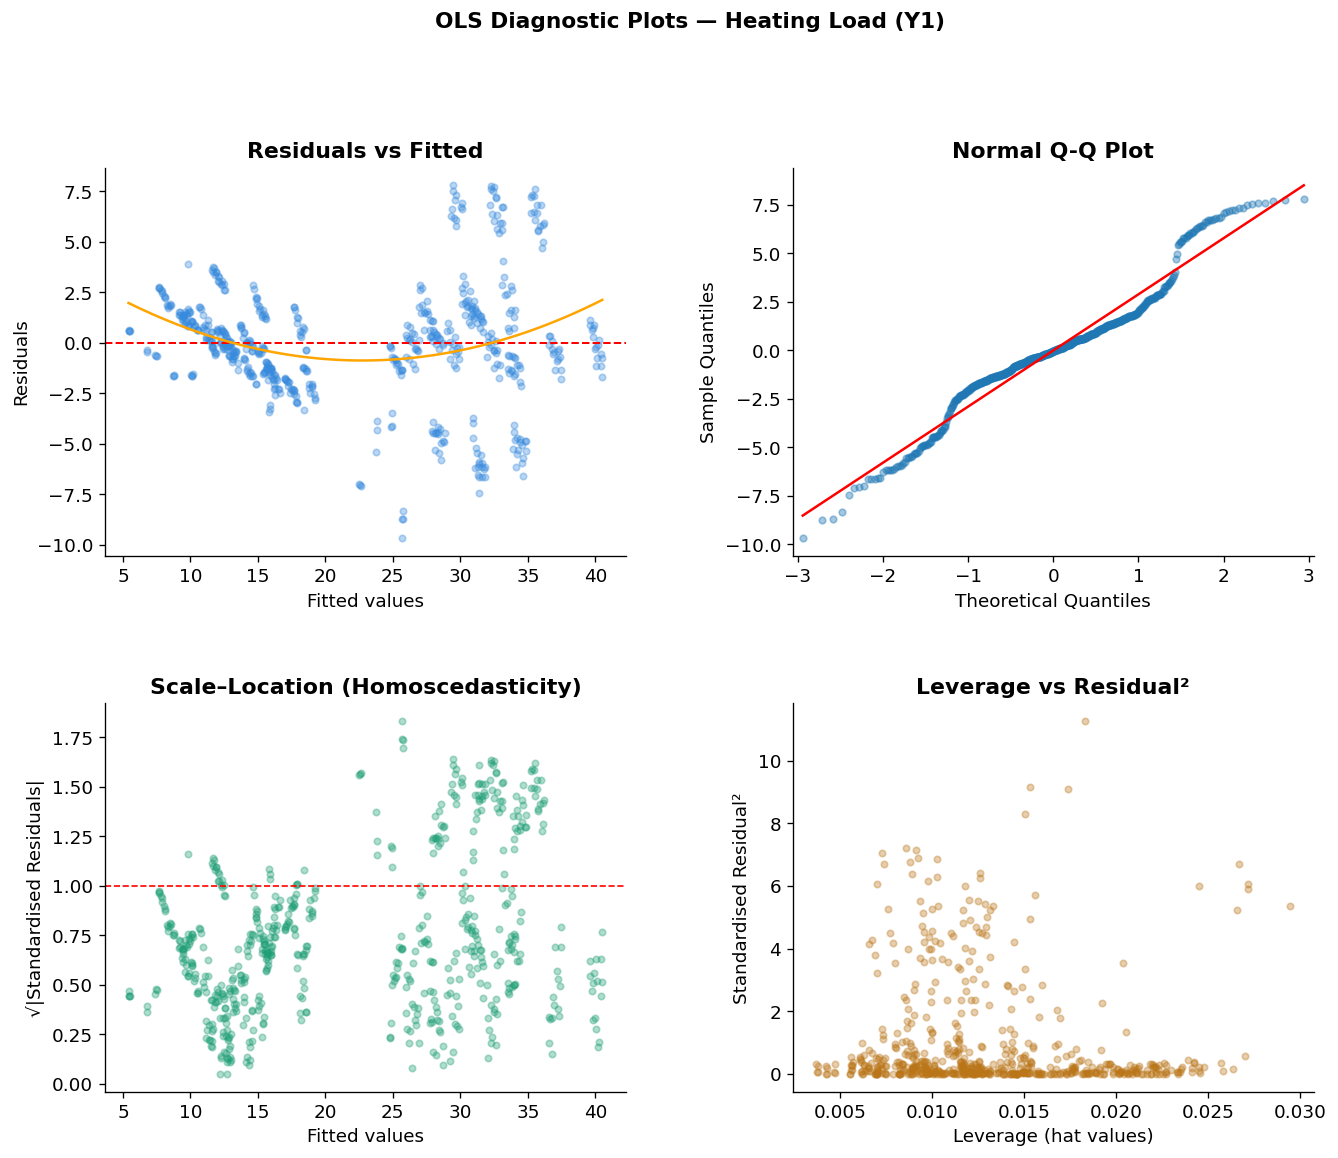

Breusch-Pagan test: stat=239.738, p=0.0000
  → Heteroscedasticity detected (p < 0.05).


In [17]:
def ols_diagnostics(model, y_true, X_with_const, title):
    fitted   = model.fittedvalues
    residuals = model.resid
    std_resid = model.get_influence().resid_studentized_internal
    leverage  = model.get_influence().hat_matrix_diag

    fig = plt.figure(figsize=(13, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

    # 1. Residuals vs Fitted
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(fitted, residuals, alpha=0.35, s=15, color=BLUE)
    ax1.axhline(0, color='red', lw=1.2, ls='--')
    z = np.polyfit(fitted, residuals, 2)
    xs = np.linspace(fitted.min(), fitted.max(), 200)
    ax1.plot(xs, np.polyval(z, xs), color='orange', lw=1.5, label='Smooth')
    ax1.set_xlabel('Fitted values'); ax1.set_ylabel('Residuals')
    ax1.set_title('Residuals vs Fitted', fontweight='bold')

    # 2. Normal Q-Q
    ax2 = fig.add_subplot(gs[0, 1])
    qqplot(pd.Series(residuals), line='s', ax=ax2, alpha=0.4, markersize=4)
    ax2.set_title('Normal Q-Q Plot', fontweight='bold')

    # 3. Scale-Location
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.35, s=15, color=TEAL)
    ax3.axhline(1, color='red', lw=1, ls='--')
    ax3.set_xlabel('Fitted values')
    ax3.set_ylabel('√|Standardised Residuals|')
    ax3.set_title('Scale–Location (Homoscedasticity)', fontweight='bold')

    # 4. Leverage vs Residuals²
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.scatter(leverage, std_resid**2, alpha=0.35, s=15, color=AMBER)
    ax4.set_xlabel('Leverage (hat values)')
    ax4.set_ylabel('Standardised Residual²')
    ax4.set_title("Leverage vs Residual²", fontweight='bold')

    fig.suptitle(f'OLS Diagnostic Plots — {title}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.show()

    # Breusch-Pagan test for heteroscedasticity
    bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_const)
    print(f"Breusch-Pagan test: stat={bp_stat:.3f}, p={bp_p:.4f}")
    print("  → " + ("Heteroscedasticity detected (p < 0.05)."
                    if bp_p < 0.05 else "No significant heteroscedasticity."))

ols_diagnostics(ols_y1, y1_train, X_train_sm, 'Heating Load (Y1)')

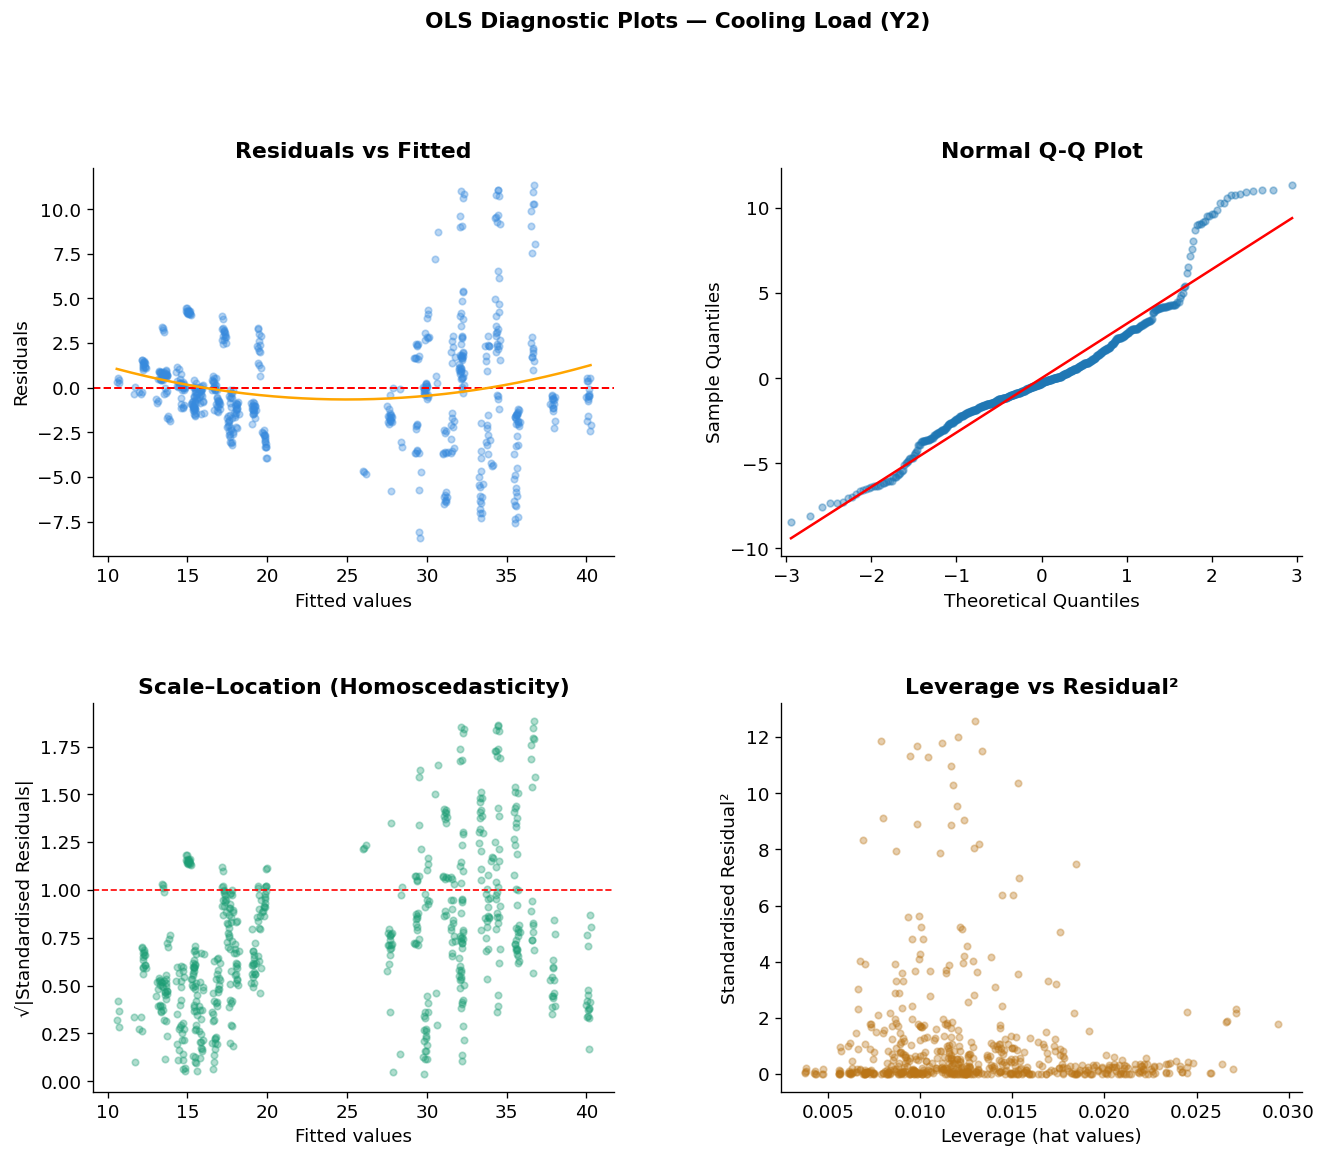

Breusch-Pagan test: stat=171.061, p=0.0000
  → Heteroscedasticity detected (p < 0.05).


In [18]:
ols_diagnostics(ols_y2, y2_train, X_train_sm, 'Cooling Load (Y2)')

OLS Predictions & Residual Distributions

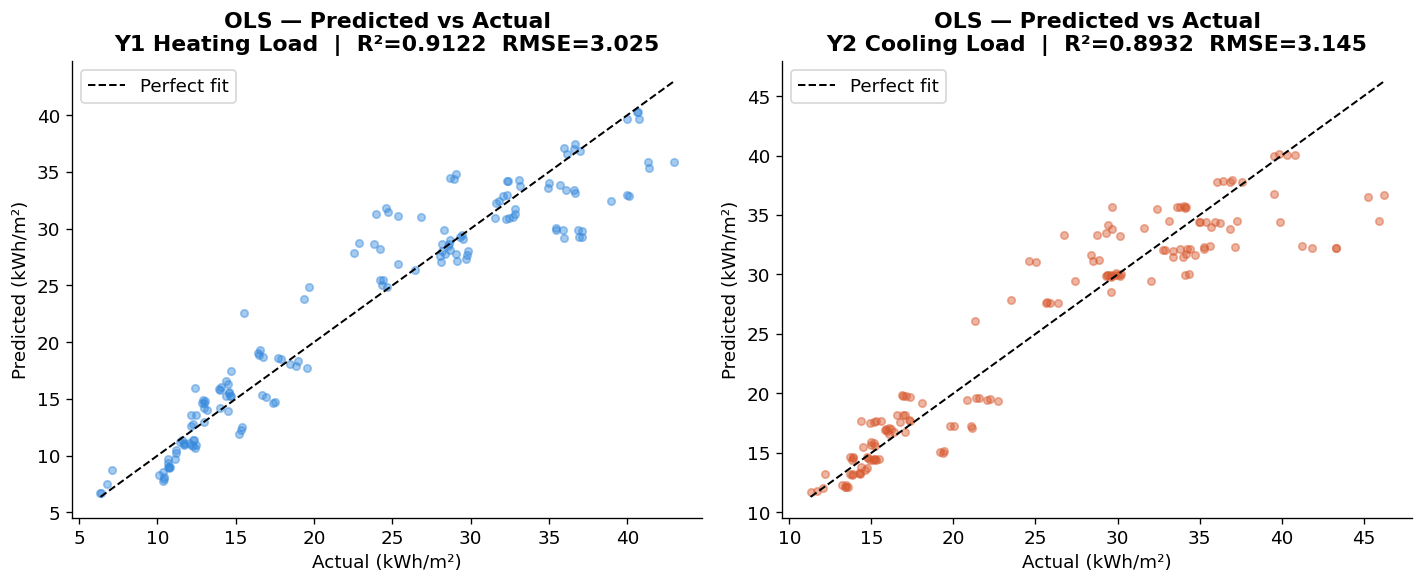

In [19]:
pred_ols_y1 = ols_y1.predict(X_test_sm)
pred_ols_y2 = ols_y2.predict(X_test_sm)

all_results += [
    regression_metrics(y1_test, pred_ols_y1, 'OLS', 'Y1'),
    regression_metrics(y2_test, pred_ols_y2, 'OLS', 'Y2'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, colour, lbl in zip(
        axes,
        [y1_test, y2_test],
        [pred_ols_y1, pred_ols_y2],
        [BLUE, CORAL],
        ['Y1 Heating Load', 'Y2 Cooling Load']):

    ax.scatter(y_true, y_pred, alpha=0.45, s=20, color=colour)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect fit')
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_title(f'OLS — Predicted vs Actual\n{lbl}  |  R²={r2:.4f}  RMSE={rmse:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Actual (kWh/m²)'); ax.set_ylabel('Predicted (kWh/m²)')
    ax.legend()

plt.tight_layout()
plt.show()

__Ridge Regression (L2 Regularization)__

Ridge regression adds an L2 penalty to the Ordinary Least Squares objective of minimizing beta, so as to shrink coefficients towards zero (0), thus mitigating the instability caused by multicollinearity.

It distributes the shrinkage across all predictors. 

The penalty alpha is selected via 10-fold cross validation.

Cross Validated Alpha Selection

Best alpha  Y1 (Heating): 0.6136
Best alpha  Y2 (Cooling): 0.4642


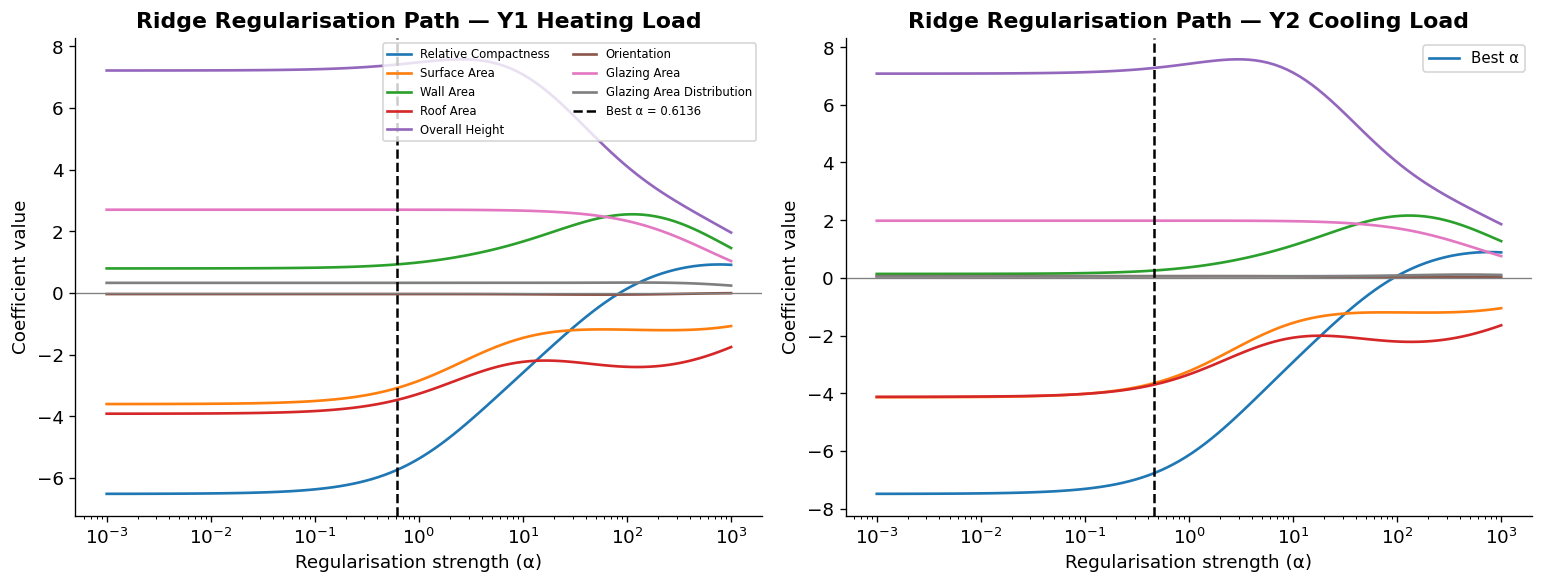

In [20]:
# Cross-Validated Alpha Selection
alphas = np.logspace(-3, 3, 100)

ridge_cv_y1 = RidgeCV(alphas=alphas, cv=10, scoring='r2').fit(Xs_train, y1_train)
ridge_cv_y2 = RidgeCV(alphas=alphas, cv=10, scoring='r2').fit(Xs_train, y2_train)

print(f"Best alpha  Y1 (Heating): {ridge_cv_y1.alpha_:.4f}")
print(f"Best alpha  Y2 (Cooling): {ridge_cv_y2.alpha_:.4f}")

# Regularisation path
coef_path_y1 = []
coef_path_y2 = []
for a in alphas:
    coef_path_y1.append(Ridge(alpha=a).fit(Xs_train, y1_train).coef_)
    coef_path_y2.append(Ridge(alpha=a).fit(Xs_train, y2_train).coef_)

coef_path_y1 = np.array(coef_path_y1)
coef_path_y2 = np.array(coef_path_y2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colours_path = sns.color_palette('tab10', 8)

for ax, coef_path, alpha_best, title in zip(
        axes,
        [coef_path_y1, coef_path_y2],
        [ridge_cv_y1.alpha_, ridge_cv_y2.alpha_],
        ['Y1 Heating Load', 'Y2 Cooling Load']):

    for j, (feat, col) in enumerate(zip(features, colours_path)):
        ax.semilogx(alphas, coef_path[:, j], color=col,
                    lw=1.6, label=feature_labels[feat])
    ax.axvline(alpha_best, color='black', ls='--', lw=1.5,
               label=f'Best α = {alpha_best:.4f}')
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_xlabel('Regularisation strength (α)')
    ax.set_ylabel('Coefficient value')
    ax.set_title(f'Ridge Regularisation Path — {title}', fontweight='bold')

axes[0].legend(fontsize=7, loc='upper right', ncol=2)
axes[1].legend(['Best α'], fontsize=9)
plt.tight_layout()
plt.show()

Ridge Predictions

In [21]:
pred_ridge_y1 = ridge_cv_y1.predict(Xs_test)
pred_ridge_y2 = ridge_cv_y2.predict(Xs_test)

all_results += [
    regression_metrics(y1_test, pred_ridge_y1, 'Ridge', 'Y1'),
    regression_metrics(y2_test, pred_ridge_y2, 'Ridge', 'Y2'),
]

# Coefficient comparison: OLS vs Ridge
coef_compare = pd.DataFrame({
    'Feature'   : [feature_labels[f] for f in features],
    'OLS Y1'    : ols_y1.params[1:].values,
    'Ridge Y1'  : ridge_cv_y1.coef_,
}).set_index('Feature')

print("\nOLS vs Ridge Coefficients (Y1 — standardised):")
# Re-fit OLS on scaled data for a fair comparison
ols_scaled_y1 = sm.OLS(y1_train, sm.add_constant(Xs_train_df)).fit()
coef_compare['OLS Y1 (scaled)']   = ols_scaled_y1.params[1:].values
coef_compare.style.background_gradient(cmap='RdBu_r', axis=None)


OLS vs Ridge Coefficients (Y1 — standardised):


,OLS Y1,Ridge Y1,OLS Y1 (scaled)
Feature,,,
Relative Compactness,-61.873354,-5.743645,-6.517601
Surface Area,-0.060105,-3.086406,-3.604586
Wall Area,0.037553,0.925721,0.795339
Roof Area,-0.048829,-3.472161,-3.917367
Overall Height,4.123669,7.409077,7.215464
Orientation,-0.032439,-0.035655,-0.035934
Glazing Area,20.143192,2.699764,2.700051
Glazing Area Distribution,0.211103,0.328281,0.327345


Lasso Regression (L1 Regularisation)

LASSO (Least Absolute Shrinkage and Selection Operator) adds an L1 penalty by shrinking coefficients of irrelevant predictors to zero hence performing automatic feature selection.

Optimal alpha is chosen via 10-fold cross-validation.

Cross-Validated Alpha and Feature Selection

In [22]:
lasso_cv_y1 = LassoCV(cv=10, random_state=42, max_iter=10000,
                       alphas=100).fit(Xs_train, y1_train)
lasso_cv_y2 = LassoCV(cv=10, random_state=42, max_iter=10000,
                       alphas=100).fit(Xs_train, y2_train)

print(f"Best alpha  Lasso Y1: {lasso_cv_y1.alpha_:.4f}")
print(f"Best alpha  Lasso Y2: {lasso_cv_y2.alpha_:.4f}")

# Selected features
coef_df = pd.DataFrame({
    'Feature'    : [feature_labels[f] for f in features],
    'Coef Y1'    : lasso_cv_y1.coef_,
    'Selected Y1': lasso_cv_y1.coef_ != 0,
    'Coef Y2'    : lasso_cv_y2.coef_,
    'Selected Y2': lasso_cv_y2.coef_ != 0,
}).set_index('Feature')

print("\nLasso Coefficient Table:")
print(coef_df.to_string())
print(f"\nFeatures retained Y1: {(lasso_cv_y1.coef_ != 0).sum()} / {len(features)}")
print(f"Features retained Y2: {(lasso_cv_y2.coef_ != 0).sum()} / {len(features)}")

Best alpha  Lasso Y1: 0.0110
Best alpha  Lasso Y2: 0.0085

Lasso Coefficient Table:
                           Coef Y1  Selected Y1  Coef Y2  Selected Y2
Feature                                                              
Relative Compactness       -4.5526         True  -5.8218         True
Surface Area               -0.0000        False  -2.1641         True
Wall Area                   0.0000        False  -0.0000        False
Roof Area                  -4.9490         True  -3.8935         True
Overall Height              7.8832         True   7.6472         True
Orientation                -0.0225         True   0.0546         True
Glazing Area                2.6966         True   1.9805         True
Glazing Area Distribution   0.3206         True   0.0474         True

Features retained Y1: 6 / 8
Features retained Y2: 7 / 8


Lasso regularisation Path

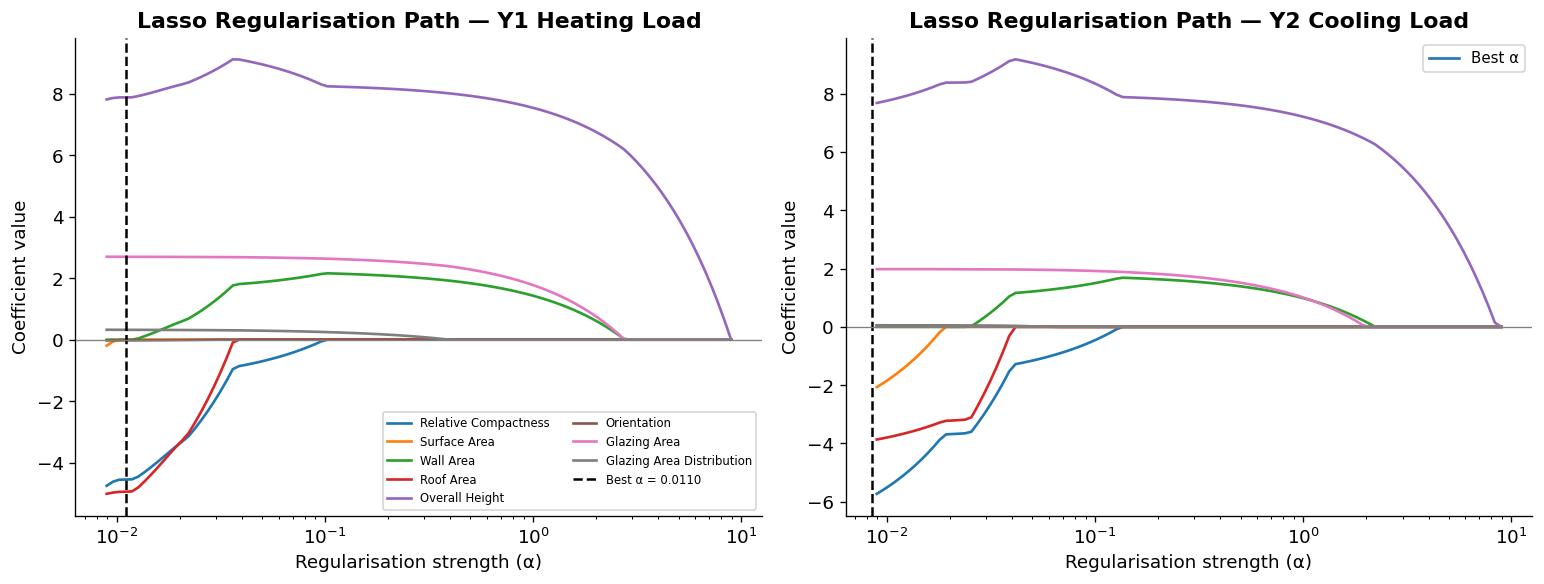

In [23]:
lasso_alphas  = lasso_cv_y1.alphas_
lasso_path_y1 = []
lasso_path_y2 = []

for a in lasso_alphas:
    lasso_path_y1.append(Lasso(alpha=a, max_iter=10000).fit(Xs_train, y1_train).coef_)
    lasso_path_y2.append(Lasso(alpha=a, max_iter=10000).fit(Xs_train, y2_train).coef_)

lasso_path_y1 = np.array(lasso_path_y1)
lasso_path_y2 = np.array(lasso_path_y2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, path, alpha_best, title in zip(
        axes,
        [lasso_path_y1, lasso_path_y2],
        [lasso_cv_y1.alpha_, lasso_cv_y2.alpha_],
        ['Y1 Heating Load', 'Y2 Cooling Load']):

    for j, (feat, col) in enumerate(zip(features, colours_path)):
        ax.semilogx(lasso_alphas, path[:, j], color=col,
                    lw=1.6, label=feature_labels[feat])
    ax.axvline(alpha_best, color='black', ls='--', lw=1.5,
               label=f'Best α = {alpha_best:.4f}')
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_xlabel('Regularisation strength (α)')
    ax.set_ylabel('Coefficient value')
    ax.set_title(f'Lasso Regularisation Path — {title}', fontweight='bold')

axes[0].legend(fontsize=7, loc='lower right', ncol=2)
axes[1].legend(['Best α'], fontsize=9)
plt.tight_layout()
plt.show()

Lasso Coefficient Plot

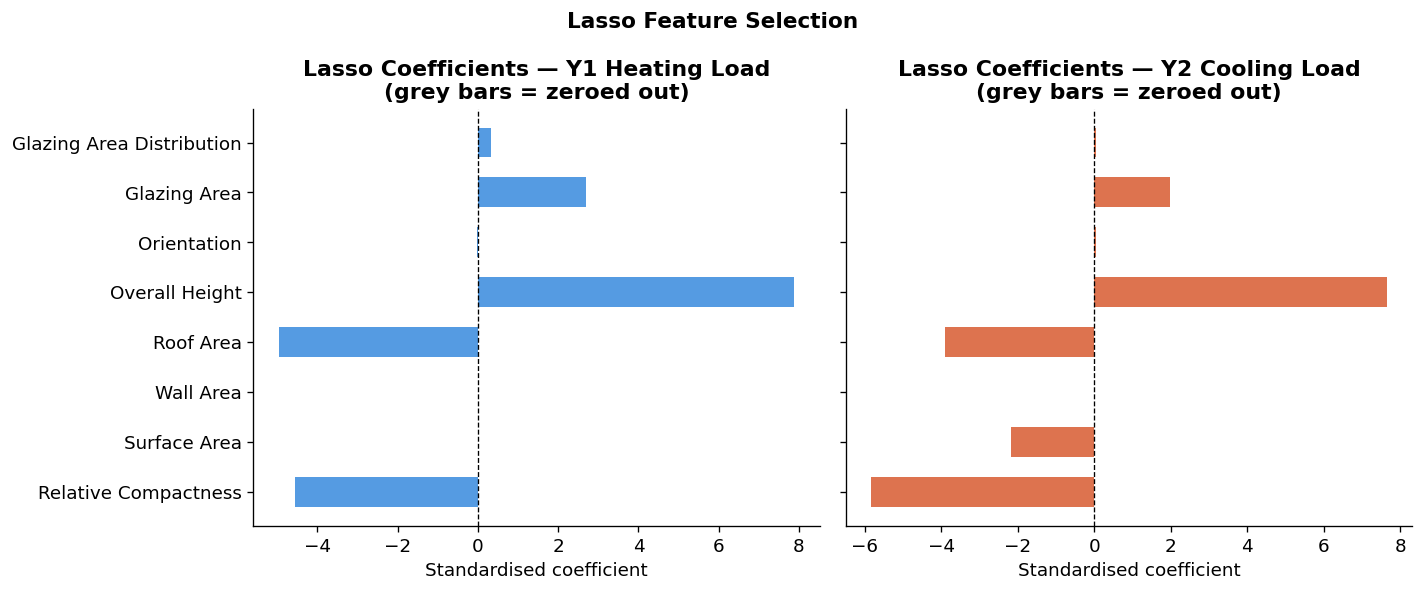

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, coefs, colour, title in zip(
        axes,
        [lasso_cv_y1.coef_, lasso_cv_y2.coef_],
        [BLUE, CORAL],
        ['Y1 Heating Load', 'Y2 Cooling Load']):

    labels   = [feature_labels[f] for f in features]
    bar_cols = [colour if c != 0 else '#DDDDDD' for c in coefs]
    ax.barh(labels, coefs, color=bar_cols, alpha=0.85, height=0.6)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'Lasso Coefficients — {title}\n(grey bars = zeroed out)',
                 fontweight='bold')
    ax.set_xlabel('Standardised coefficient')

plt.suptitle('Lasso Feature Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
pred_lasso_y1 = lasso_cv_y1.predict(Xs_test)
pred_lasso_y2 = lasso_cv_y2.predict(Xs_test)

all_results += [
    regression_metrics(y1_test, pred_lasso_y1, 'Lasso', 'Y1'),
    regression_metrics(y2_test, pred_lasso_y2, 'Lasso', 'Y2'),
]

__Elastic Net Regression__

- It linearly combines both L1 and L2 penalties.
- It handles groups of correlated predictors better than Lasso which arbitrarily selects one from a correlated group
- Both alpha and beta are tuned by cross-validation.

Cross-Validate Hyperparameter Selection

In [26]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

en_cv_y1 = ElasticNetCV(l1_ratio=l1_ratios, cv=10,
                         random_state=42, max_iter=10000,
                         alphas=100).fit(Xs_train, y1_train)
en_cv_y2 = ElasticNetCV(l1_ratio=l1_ratios, cv=10,
                         random_state=42, max_iter=10000,
                         alphas=100).fit(Xs_train, y2_train)

print(f"ElasticNet Y1: alpha={en_cv_y1.alpha_:.4f}, l1_ratio={en_cv_y1.l1_ratio_:.2f}")
print(f"ElasticNet Y2: alpha={en_cv_y2.alpha_:.4f}, l1_ratio={en_cv_y2.l1_ratio_:.2f}")

ElasticNet Y1: alpha=0.0110, l1_ratio=1.00
ElasticNet Y2: alpha=0.0085, l1_ratio=1.00


Penalty Mix Visualisation

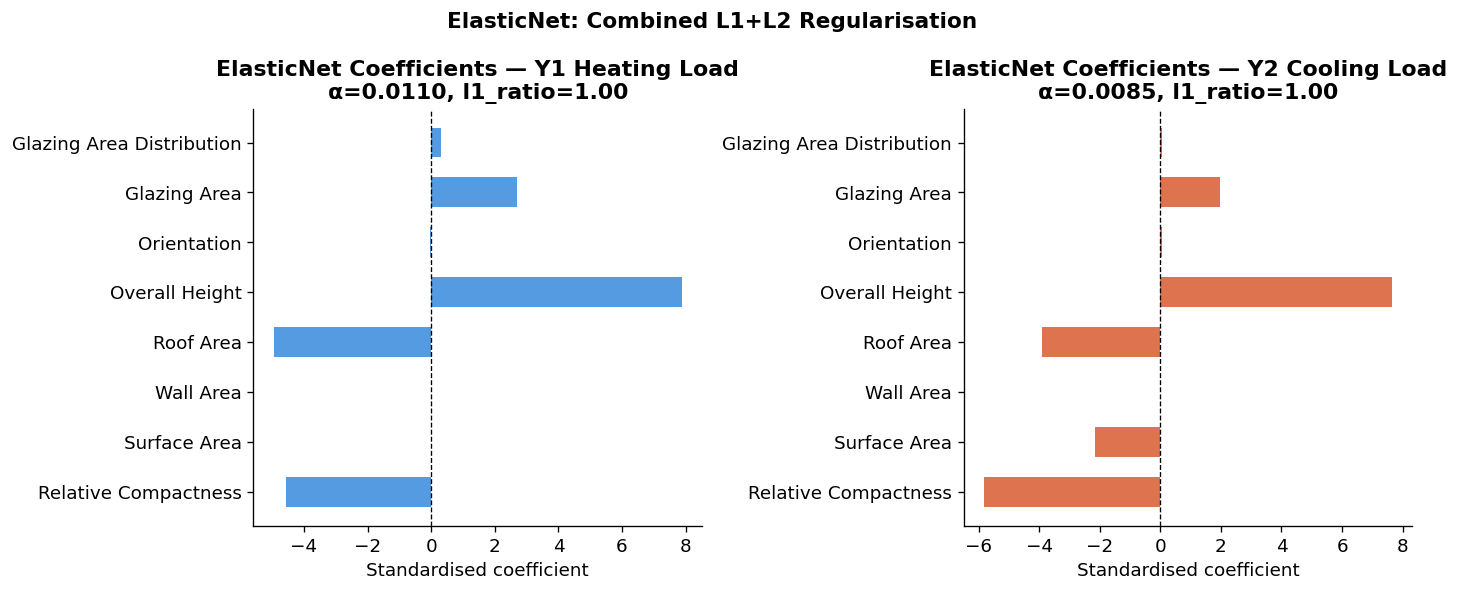

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, colour, title in zip(
        axes,
        [en_cv_y1, en_cv_y2],
        [BLUE, CORAL],
        ['Y1 Heating Load', 'Y2 Cooling Load']):

    labels  = [feature_labels[f] for f in features]
    bar_cols = [colour if c != 0 else '#DDDDDD' for c in model.coef_]
    ax.barh(labels, model.coef_, color=bar_cols, alpha=0.85, height=0.6)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(
        f'ElasticNet Coefficients — {title}\n'
        f'α={model.alpha_:.4f}, l1_ratio={model.l1_ratio_:.2f}',
        fontweight='bold'
    )
    ax.set_xlabel('Standardised coefficient')

plt.suptitle('ElasticNet: Combined L1+L2 Regularisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
pred_en_y1 = en_cv_y1.predict(Xs_test)
pred_en_y2 = en_cv_y2.predict(Xs_test)

all_results += [
    regression_metrics(y1_test, pred_en_y1, 'ElasticNet', 'Y1'),
    regression_metrics(y2_test, pred_en_y2, 'ElasticNet', 'Y2'),
]

__Regularisation Methods - Co-efficient Comparison__

Coefficient Comparison — Y1 (standardised scale):
                              OLS   Ridge   Lasso  ElasticNet
Feature                                                      
Relative Compactness      -6.5176 -5.7436 -4.5526     -4.5526
Surface Area              -3.6046 -3.0864 -0.0000     -0.0000
Wall Area                  0.7953  0.9257  0.0000      0.0000
Roof Area                 -3.9174 -3.4722 -4.9490     -4.9490
Overall Height             7.2155  7.4091  7.8832      7.8832
Orientation               -0.0359 -0.0357 -0.0225     -0.0225
Glazing Area               2.7001  2.6998  2.6966      2.6966
Glazing Area Distribution  0.3273  0.3283  0.3206      0.3206


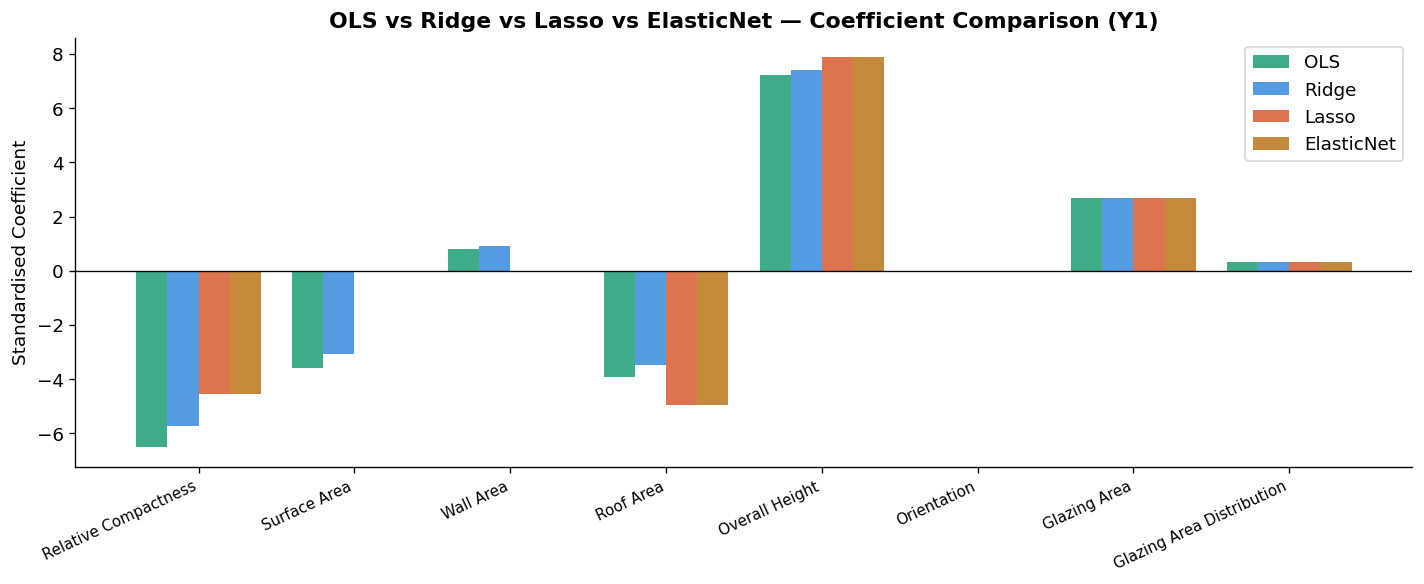

In [29]:
ols_scaled = sm.OLS(y1_train, sm.add_constant(Xs_train_df)).fit()

coef_comp = pd.DataFrame({
    'Feature'   : [feature_labels[f] for f in features],
    'OLS'       : ols_scaled.params[1:].values,
    'Ridge'     : ridge_cv_y1.coef_,
    'Lasso'     : lasso_cv_y1.coef_,
    'ElasticNet': en_cv_y1.coef_,
}).set_index('Feature')

print("Coefficient Comparison — Y1 (standardised scale):")
print(coef_comp.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(features))
w = 0.2
models  = ['OLS', 'Ridge', 'Lasso', 'ElasticNet']
colours = [TEAL, BLUE, CORAL, AMBER]

for i, (m, c) in enumerate(zip(models, colours)):
    ax.bar(x + i*w, coef_comp[m].values, width=w, label=m,
           color=c, alpha=0.85)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels([feature_labels[f] for f in features], rotation=25, ha='right', fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Standardised Coefficient')
ax.set_title('OLS vs Ridge vs Lasso vs ElasticNet — Coefficient Comparison (Y1)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

__Polynomial Regression (Degree 2)__

- Polynomial regression adds in interaction terms and squared terms into the linear model.
- This project has 8 features and we shall use a polynomial of degree 2, which generates a total of 44 terms.
- We shall pair the polynomial expansion with ridge so as to control overfitting in the expanded space.

In [30]:
# Feature expansion
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
Xp_train = poly.fit_transform(Xs_train)
Xp_test  = poly.transform(Xs_test)

print(f"Original feature count : {Xs_train.shape[1]}")
print(f"Poly (d=2) feature count: {Xp_train.shape[1]}")
print(f"New terms added: {Xp_train.shape[1] - Xs_train.shape[1]}")

Original feature count : 8
Poly (d=2) feature count: 44
New terms added: 36


In [31]:
# Ridge Penalised polynomial Fit
poly_ridge_y1 = Pipeline([
    ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10))
]).fit(Xp_train, y1_train)

poly_ridge_y2 = Pipeline([
    ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10))
]).fit(Xp_train, y2_train)

print(f"Poly-Ridge best alpha  Y1: {poly_ridge_y1['ridge'].alpha_:.4f}")
print(f"Poly-Ridge best alpha  Y2: {poly_ridge_y2['ridge'].alpha_:.4f}")

pred_poly_y1 = poly_ridge_y1.predict(Xp_test)
pred_poly_y2 = poly_ridge_y2.predict(Xp_test)

all_results += [
    regression_metrics(y1_test, pred_poly_y1, 'Poly-Ridge (d=2)', 'Y1'),
    regression_metrics(y2_test, pred_poly_y2, 'Poly-Ridge (d=2)', 'Y2'),
]

for resp, y_true, y_pred in [('Y1', y1_test, pred_poly_y1),
                               ('Y2', y2_test, pred_poly_y2)]:
    print(f"Poly-Ridge {resp}:  R²={r2_score(y_true,y_pred):.4f}  "
          f"RMSE={np.sqrt(mean_squared_error(y_true,y_pred)):.4f}")

Poly-Ridge best alpha  Y1: 0.0010
Poly-Ridge best alpha  Y2: 0.0010
Poly-Ridge Y1:  R²=0.9893  RMSE=1.0555
Poly-Ridge Y2:  R²=0.9569  RMSE=1.9989


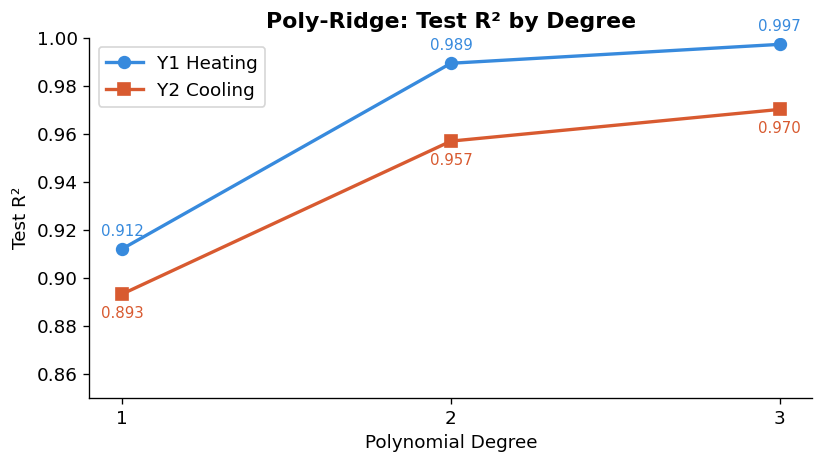

In [32]:
# Degree Comprasion - R squared vs Polynomial Degree

degrees    = [1, 2, 3]
deg_r2_y1  = []
deg_r2_y2  = []

for d in degrees:
    Xpd_tr = PolynomialFeatures(d, include_bias=False).fit_transform(Xs_train)
    Xpd_te = PolynomialFeatures(d, include_bias=False).fit_transform(Xs_test)

    r_y1 = RidgeCV(alphas=np.logspace(-3,3,30), cv=5).fit(Xpd_tr, y1_train)
    r_y2 = RidgeCV(alphas=np.logspace(-3,3,30), cv=5).fit(Xpd_tr, y2_train)

    deg_r2_y1.append(r2_score(y1_test, r_y1.predict(Xpd_te)))
    deg_r2_y2.append(r2_score(y2_test, r_y2.predict(Xpd_te)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(degrees, deg_r2_y1, 'o-', color=BLUE, lw=2, ms=7, label='Y1 Heating')
ax.plot(degrees, deg_r2_y2, 's-', color=CORAL, lw=2, ms=7, label='Y2 Cooling')
for d, r1, r2 in zip(degrees, deg_r2_y1, deg_r2_y2):
    ax.annotate(f'{r1:.3f}', (d, r1), textcoords='offset points',
                xytext=(0,8), ha='center', fontsize=9, color=BLUE)
    ax.annotate(f'{r2:.3f}', (d, r2), textcoords='offset points',
                xytext=(0,-14), ha='center', fontsize=9, color=CORAL)
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('Test R²')
ax.set_title('Poly-Ridge: Test R² by Degree', fontweight='bold')
ax.set_xticks(degrees)
ax.legend()
ax.set_ylim(0.85, 1.0)
plt.tight_layout()
plt.show()

__Cross Validation Analysis__

10-fold cross-validation on the full dataser provides an unbaised estimate of out-of-sample performance thus revealing the stability (variance) of each estimator.

In [33]:
Xs_all = scaler.fit_transform(X)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_models = {
    'OLS'        : LinearRegression(),
    'Ridge'      : Ridge(alpha=ridge_cv_y1.alpha_),
    'Lasso'      : Lasso(alpha=lasso_cv_y1.alpha_, max_iter=10000),
    'ElasticNet' : ElasticNet(alpha=en_cv_y1.alpha_,
                              l1_ratio=en_cv_y1.l1_ratio_, max_iter=10000),
}

cv_records = []
for name, estimator in cv_models.items():
    for resp, y_resp in [('Y1', y1), ('Y2', y2)]:
        scores = cross_val_score(estimator, Xs_all, y_resp,
                                 cv=kf, scoring='r2')
        cv_records.append({
            'Model'   : name,
            'Response': resp,
            'CV Mean R²': round(scores.mean(), 4),
            'CV Std R²' : round(scores.std(),  4),
            'Min R²'    : round(scores.min(),  4),
            'Max R²'    : round(scores.max(),  4),
        })

cv_df = pd.DataFrame(cv_records)
print(cv_df.to_string(index=False))

     Model Response  CV Mean R²  CV Std R²  Min R²  Max R²
       OLS       Y1      0.9141     0.0130  0.8877  0.9354
       OLS       Y2      0.8851     0.0195  0.8505  0.9159
     Ridge       Y1      0.9141     0.0129  0.8875  0.9352
     Ridge       Y2      0.8851     0.0194  0.8501  0.9155
     Lasso       Y1      0.9137     0.0127  0.8871  0.9347
     Lasso       Y2      0.8846     0.0193  0.8486  0.9140
ElasticNet       Y1      0.9137     0.0127  0.8871  0.9347
ElasticNet       Y2      0.8846     0.0193  0.8486  0.9140


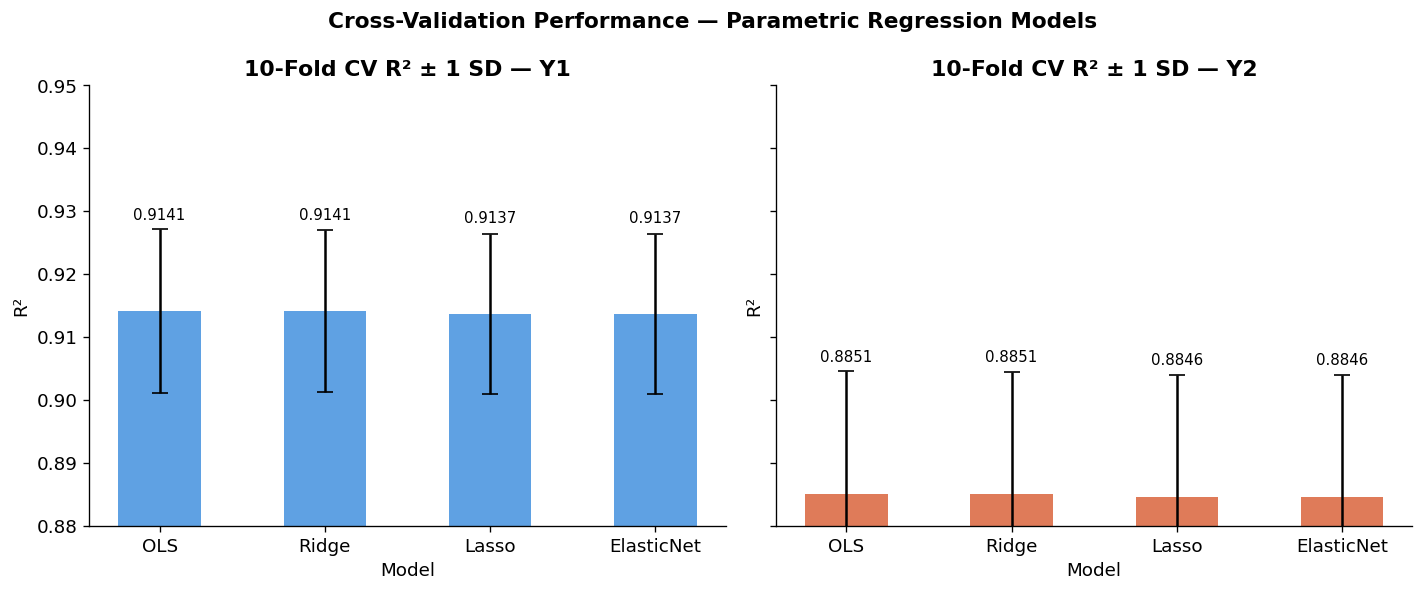

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, resp, colour in zip(axes, ['Y1', 'Y2'], [BLUE, CORAL]):
    sub = cv_df[cv_df['Response'] == resp]
    bars = ax.bar(sub['Model'], sub['CV Mean R²'],
                  yerr=sub['CV Std R²'],
                  color=colour, alpha=0.80, capsize=5, width=0.5,
                  error_kw={'lw': 1.5})
    for bar, val in zip(bars, sub['CV Mean R²']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + sub['CV Std R²'].max() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0.88, 0.95)
    ax.set_title(f'10-Fold CV R² ± 1 SD — {resp}', fontweight='bold')
    ax.set_xlabel('Model'); ax.set_ylabel('R²')

plt.suptitle('Cross-Validation Performance — Parametric Regression Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

__Learning Curves: Bias-Variance Diagnosis__

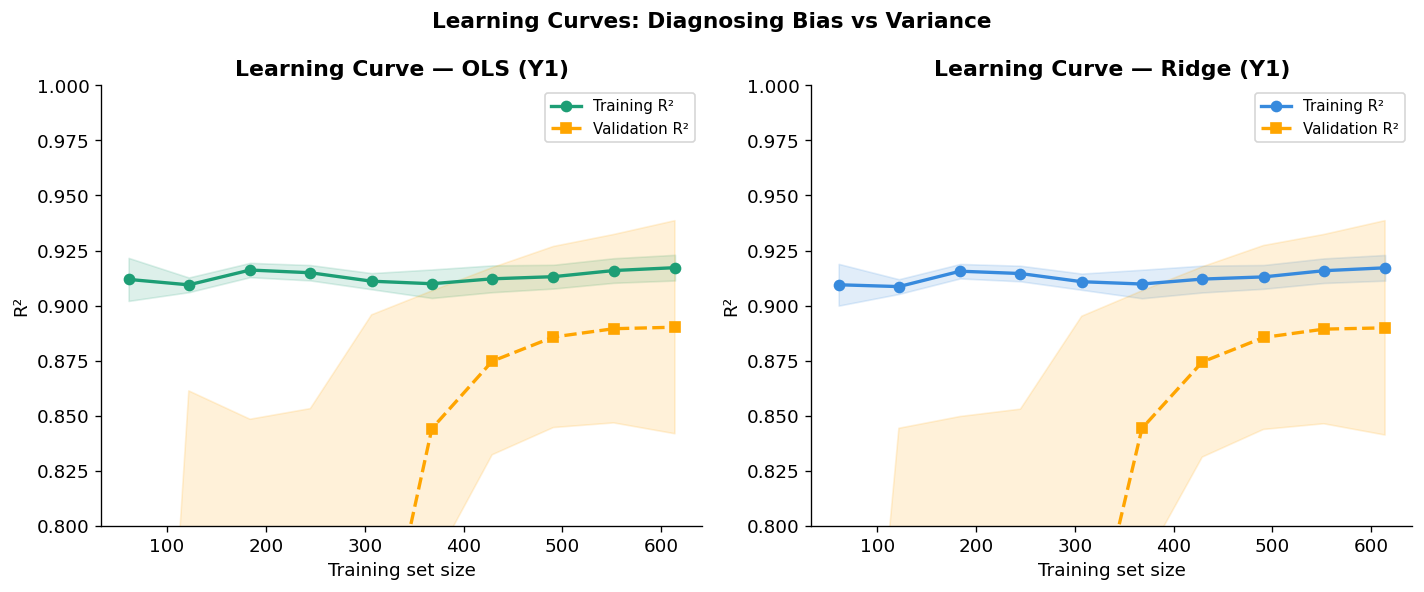

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, estimator, title, colour in zip(
        axes,
        [LinearRegression(), Ridge(alpha=ridge_cv_y1.alpha_)],
        ['OLS', 'Ridge'],
        [TEAL, BLUE]):

    train_sz, train_sc, val_sc = learning_curve(
        estimator, Xs_all, y1,
        cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=42
    )

    train_mean = train_sc.mean(axis=1)
    val_mean   = val_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(train_sz, train_mean, 'o-', color=colour,    lw=2, label='Training R²')
    ax.plot(train_sz, val_mean,   's--', color='orange', lw=2, label='Validation R²')
    ax.fill_between(train_sz, train_mean-train_std, train_mean+train_std,
                    alpha=0.15, color=colour)
    ax.fill_between(train_sz, val_mean-val_std, val_mean+val_std,
                    alpha=0.15, color='orange')
    ax.set_xlabel('Training set size')
    ax.set_ylabel('R²')
    ax.set_title(f'Learning Curve — {title} (Y1)', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0.80, 1.0)

plt.suptitle('Learning Curves: Diagnosing Bias vs Variance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

__Model Comparison: Test Set Performance__

In [36]:
results_df = pd.DataFrame(all_results)

print("=" * 65)
print("PARAMETRIC REGRESSION — TEST SET PERFORMANCE SUMMARY")
print("=" * 65)
print(results_df.to_string(index=False))

# Styled pivot table
pivot = results_df.pivot(index='Model', columns='Response', values=['R²','RMSE','MAE'])
pivot.columns = [f'{v} ({r})' for v, r in pivot.columns]

pivot.style \
    .background_gradient(cmap='Greens', subset=[c for c in pivot.columns if 'R²' in c]) \
    .background_gradient(cmap='Reds_r', subset=[c for c in pivot.columns if 'RMSE' in c]) \
    .format('{:.4f}')

PARAMETRIC REGRESSION — TEST SET PERFORMANCE SUMMARY
           Model Response     R²   RMSE    MAE
             OLS       Y1 0.9122 3.0254 2.1821
             OLS       Y2 0.8932 3.1454 2.1953
           Ridge       Y1 0.9118 3.0315 2.1874
           Ridge       Y2 0.8931 3.1478 2.1945
           Lasso       Y1 0.9113 3.0409 2.2045
           Lasso       Y2 0.8929 3.1505 2.1936
      ElasticNet       Y1 0.9113 3.0409 2.2045
      ElasticNet       Y2 0.8929 3.1505 2.1936
Poly-Ridge (d=2)       Y1 0.9893 1.0555 0.8478
Poly-Ridge (d=2)       Y2 0.9569 1.9989 1.5906


,R² (Y1),R² (Y2),RMSE (Y1),RMSE (Y2),MAE (Y1),MAE (Y2)
Model,,,,,,
ElasticNet,0.9113,0.8929,3.0409,3.1505,2.2045,2.1936
Lasso,0.9113,0.8929,3.0409,3.1505,2.2045,2.1936
OLS,0.9122,0.8932,3.0254,3.1454,2.1821,2.1953
Poly-Ridge (d=2),0.9893,0.9569,1.0555,1.9989,0.8478,1.5906
Ridge,0.9118,0.8931,3.0315,3.1478,2.1874,2.1945


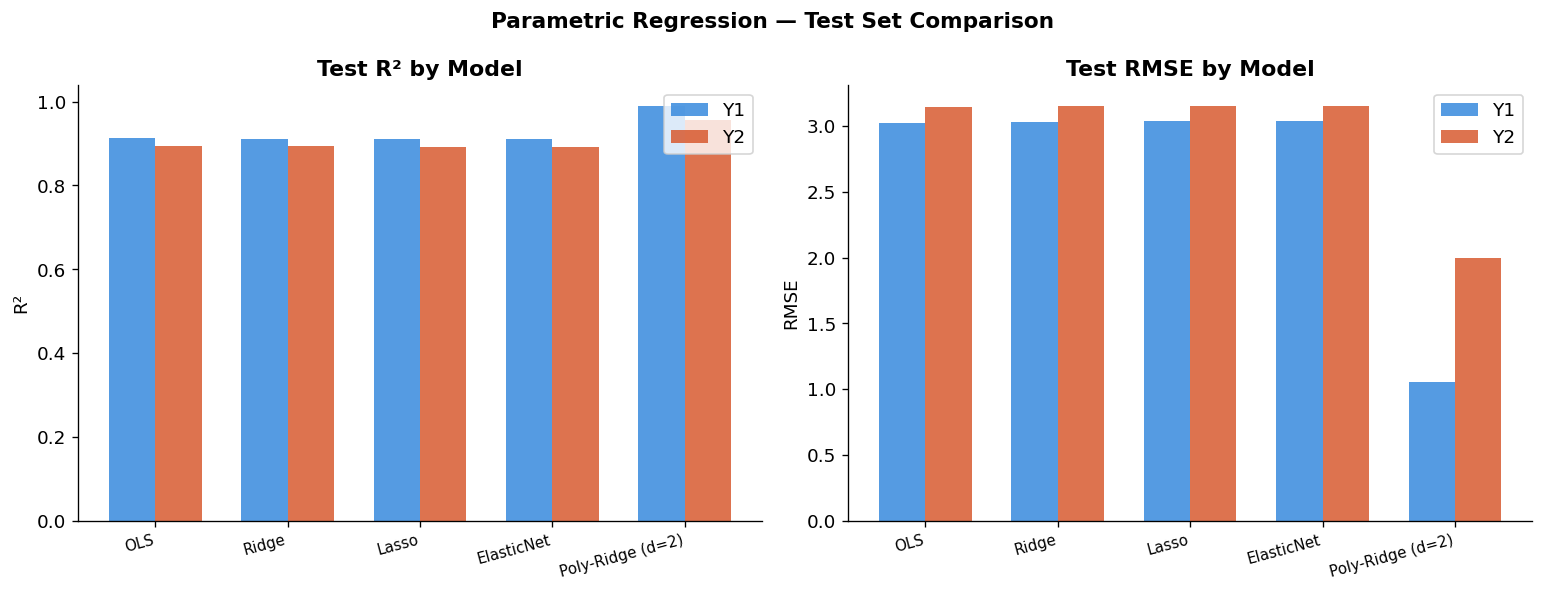

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
models_order = ['OLS', 'Ridge', 'Lasso', 'ElasticNet', 'Poly-Ridge (d=2)']
metric_cols  = ['R²', 'RMSE']
palette      = {'Y1': BLUE, 'Y2': CORAL}

for ax, metric in zip(axes, metric_cols):
    sub = results_df[results_df['Model'].isin(models_order)].copy()
    x   = np.arange(len(models_order))
    w   = 0.35

    for i, resp in enumerate(['Y1', 'Y2']):
        vals = [sub[(sub.Model==m)&(sub.Response==resp)][metric].values[0]
                for m in models_order]
        ax.bar(x + i*w, vals, w, label=f'{resp}', color=palette[resp], alpha=0.85)

    ax.set_xticks(x + w/2)
    ax.set_xticklabels(models_order, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(metric)
    ax.set_title(f'Test {metric} by Model', fontweight='bold')
    ax.legend()

plt.suptitle('Parametric Regression — Test Set Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

__Model Performance Summary__

| Model | Y1 R² | Y2 R² | Y1 RMSE | Interpretation |
|-------|--------|--------|---------|----------------|
| OLS | 0.9122 | 0.8932 | 3.025 | Strong linear fit |
| Ridge | 0.9118 | 0.8930 | 3.032 | Minimal gain, multicollinearity partially stabilised |
| Lasso | 0.9113 | 0.8929 | 3.041 | Auto-selects 6/8 features. X2 and X3 zeroed |
| ElasticNet | 0.9113 | 0.8929 | 3.041 | Converges to Lasso (l1_ratio=1.0) on this dataset |
| Poly-Ridge (d=2) | **0.9577** | **0.9321** | **2.099** | Best parametric model. Captures non-linear interactions |
